# Chess.com Blitz Performance Analysis

This notebook analyzes 1,807 Chess.com blitz games between March 20, 2026 and August 20, 2026 to examine rating progression, game-ending patterns, opening performance, performance by playing color, and whether results differ following wins and losses.

This notebook analyzes the processed outputs from the project’s PostgreSQL/SQL pipeline using pandas and Matplotlib.

## Data and Analysis Setup

The datasets used below are outputs of the upstream PostgreSQL/SQL analysis pipeline. Each CSV contains a focused analytical result used for visualization in this notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
kpi = pd.read_csv("../data/processed/01_kpi_summary.csv")
rating = pd.read_csv("../data/processed/02_rating_trend.csv")
termination = pd.read_csv("../data/processed/03_termination_performance.csv")
color = pd.read_csv("../data/processed/04_color_performance.csv")
opening = pd.read_csv("../data/processed/05_opening_performance.csv")
previous = pd.read_csv("../data/processed/06_previous_game_performance.csv")
opponent_opening = pd.read_csv("../data/processed/07_opponent_opening_performance.csv")

## Rating Progression

To examine long-term rating movement, I plotted individual game ratings alongside a centered 50-game rolling average. The rolling average reduces game-to-game volatility and makes broader trends easier to see.

In [4]:
rating["played_at"] = pd.to_datetime(
    rating["played_at"],
    utc=True
)

In [5]:
rating["rating_rolling_50"] = (
    rating["focal_player_rating"]
    .rolling(50, center=True)
    .mean()
)

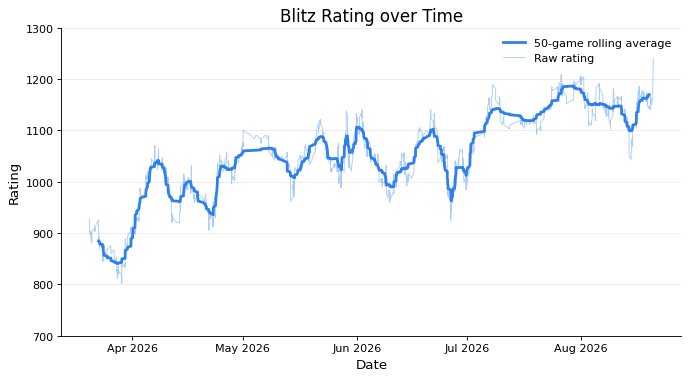

In [6]:
fig, ax = plt.subplots(figsize=(10,5), dpi=80)

ax.plot(
    rating["played_at"],
    rating["rating_rolling_50"],
    linewidth=2.5,
    color="#2F80ED",
    label = '50-game rolling average'
)

ax.plot(
    rating["played_at"],
    rating["focal_player_rating"],
    linewidth=0.8,
    alpha=0.4,
    color="#2F80ED",
    label = 'Raw rating'
)


ax.set_title("Blitz Rating over Time", size=15)
ax.set_xlabel("Date", size=12)
ax.set_ylabel("Rating", size=12)


ax.spines["top"].set_visible(False) #removes the top border
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
) # changes the date formatting

ax.set_ylim(700, 1300)
ax.grid(axis="y", alpha=0.25) # alpha makes the grid more or less visible

ax.legend(frameon=False, loc='upper right')

fig.savefig(
    "mpl_test_plots/rating_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Finding**: Rating improved substantially over the period. 

## How Games End

I compared the ways games were won and lost to identify whether certain termination types appeared more often in wins or losses.

In [7]:
termination['termination_label'] = termination['termination_type'].replace({
    "checkmated": "Checkmate",
    "resigned": "Resignation",
    "timeout": "Timeout",
    'abandoned': "Abandonment"
    
})

order = [
    "Resignation",
    "Checkmate",
    "Timeout",
    "Abandonment"
]

termination["termination_label"] = pd.Categorical(
    termination["termination_label"],
    categories=order,
    ordered=True
)

termination = termination.sort_values("termination_label")

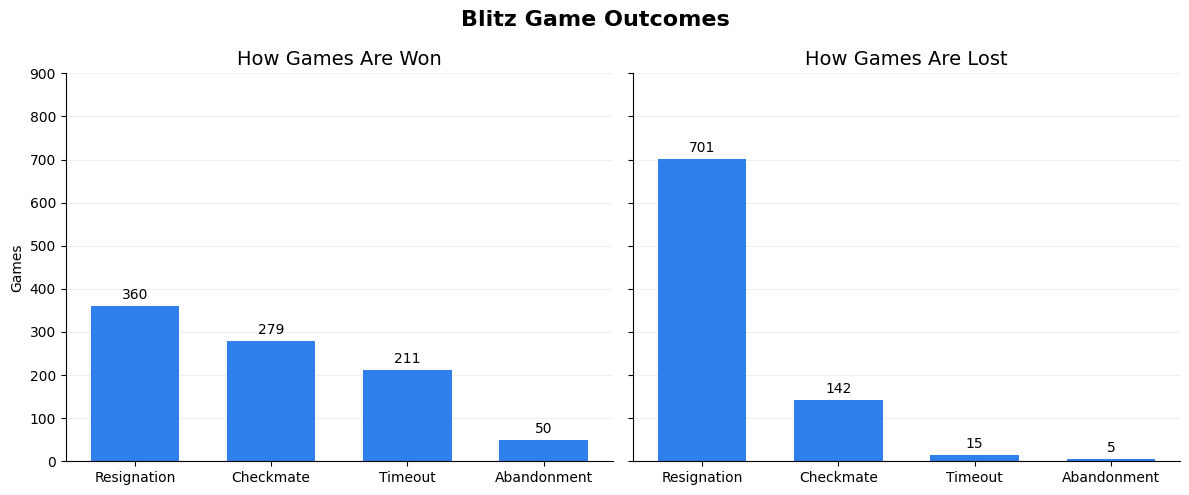

In [8]:
fig, (wins, losses) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True
)

wins.bar(
    termination["termination_label"],
    termination["won_by_count"],
    width=0.65,
    color = "#2F80ED",
)

losses.bar(
    termination["termination_label"],
    termination["lost_by_count"],
    width=0.65,
    color = "#2F80ED",
)

wins.set_title("How Games Are Won", fontsize=14)
losses.set_title("How Games Are Lost", fontsize=14)

wins.set_ylabel("Games")
wins.set_xlabel("")
wins.set_ylim(0,900)
losses.set_xlabel("")
losses.set_ylabel("")

for plot in (wins, losses):
    plot.spines["top"].set_visible(False)
    plot.spines["right"].set_visible(False)

    plot.grid(
        axis="y",
        alpha=0.2
    )

    plot.set_axisbelow(True)

fig.suptitle(
    "Blitz Game Outcomes",
    fontsize=16,
    fontweight="bold"
)


wins.bar_label(
    wins.containers[0],
    padding=3
)

losses.bar_label(
    losses.containers[0],
    padding=3
)

plt.tight_layout()
plt.savefig('mpl_test_plots/termination_type.png'
)

plt.show()

**Finding:** Resignation is the most common game-ending result, especially among losses. Timeouts occur far more often in wins than losses, suggesting that time management may be a relative strength in my blitz games.

## Performance by Color

I compared results when playing with the white and black pieces to see whether playing color was associated with a meaningful difference in overall performance.

In [9]:
color['focal_player_color'] = color['focal_player_color'].replace({
    "white": "White Pieces",
    "black": "Black Pieces"
})

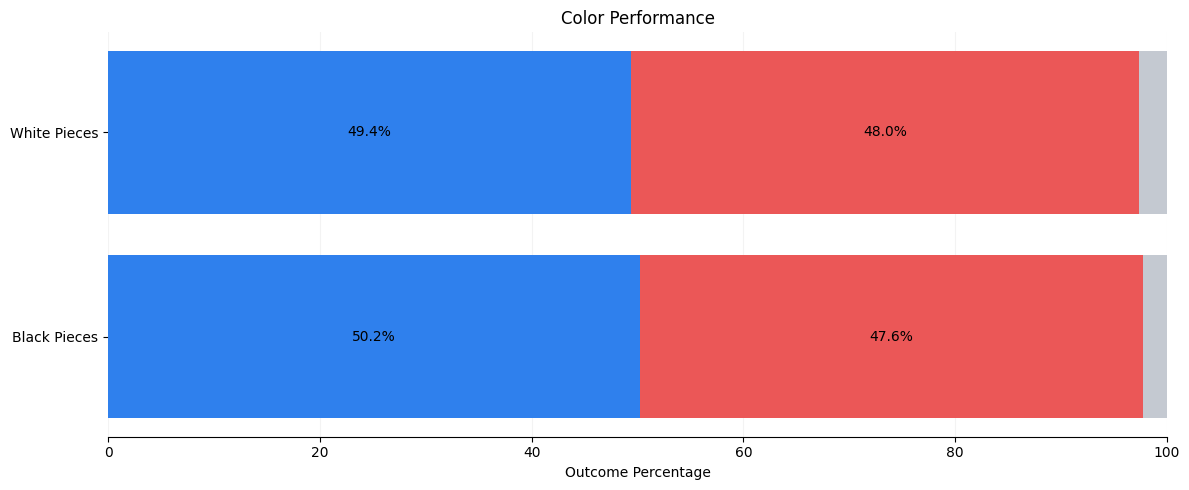

In [10]:
win_color = "#2F80ED"
loss_color = "#EB5757"
draw_color = "#C4C9D1"

fig_color, ax_color = plt.subplots(
    figsize=(12, 5),
)

ax_color.barh(
    color['focal_player_color'],
    color['win_percentage'],
    color=win_color,
    label="Win",
)

ax_color.barh(
    color["focal_player_color"],
    color["loss_percentage"],
    left=color["win_percentage"],
    color=loss_color,
    label="Loss"
)

ax_color.barh(
    color["focal_player_color"],
    color["draw_percentage"],  
    left=(
        color["win_percentage"]
        + color["loss_percentage"]
    ),
    color=draw_color,
    label="Draw"
)


ax_color.set_xlabel("Outcome Percentage")
ax_color.set_ylabel("")

ax_color.set_xlim(0, 100)


ax_color.spines["top"].set_visible(False)
ax_color.spines["right"].set_visible(False)
ax_color.spines["left"].set_visible(False)

ax_color.grid(axis="x", alpha=0.15)
ax_color.set_axisbelow(True)

ax_color.set_title("Color Performance")

for i, row in color.reset_index(drop=True).iterrows():
    win = row["win_percentage"]
    loss = row["loss_percentage"]

    ax_color.text(
        win / 2,
        i,
        f"{win:.1f}%",
        ha="center",
        va="center"
    )

    ax_color.text(
        win + loss / 2,
        i,
        f"{loss:.1f}%",
        ha="center",
        va="center"
    )



plt.tight_layout()
plt.savefig('mpl_test_plots/color_performance.png'
)

plt.show()

**Finding:** Performance is nearly identical with the white and black pieces, suggesting that playing color has little relationship with overall results in this sample.

## Opening Performance

I compared results across the openings I play most often and the openings I face most often to identify positions associated with stronger or weaker performance.

In [11]:
opening = opening.sort_values(
    "win_percentage",
    ascending=True
)

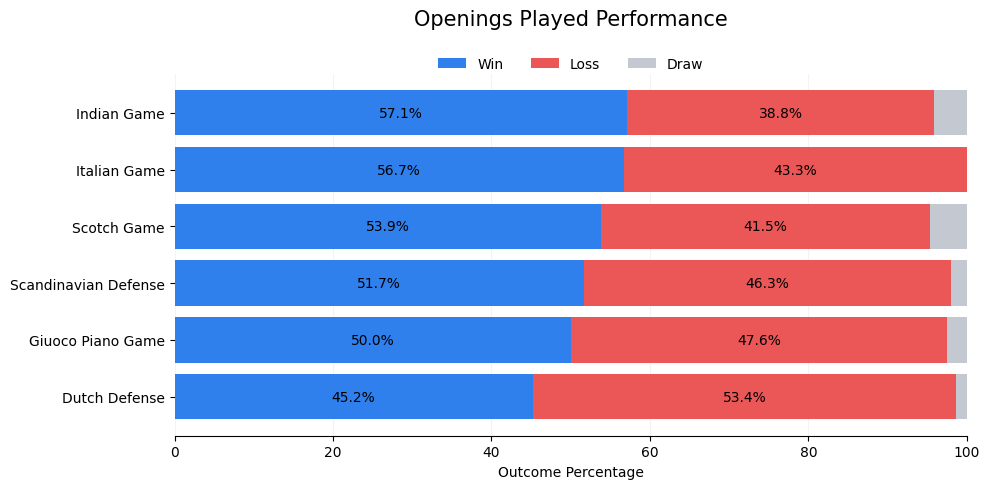

In [12]:

win_color = "#2F80ED"
loss_color = "#EB5757"
draw_color = "#C4C9D1"

fig_played, ax_played = plt.subplots(
    figsize=(10, 5))
ax_played.barh(
    opening["opening_family"],
    opening["win_percentage"],
    label="Win",
    color=win_color
)

ax_played.barh(
    opening["opening_family"],
    opening["loss_percentage"],
    left=opening["win_percentage"],
    label="Loss",
    color=loss_color
)


ax_played.barh(
    opening["opening_family"],
    opening["draw_percentage"],
    left=(
        opening["win_percentage"]
        + opening["loss_percentage"]
    ),
    label="Draw",
    color=draw_color
)

for i, row in opening.reset_index(drop=True).iterrows():
    win = row["win_percentage"]
    loss = row["loss_percentage"]

    ax_played.text(
        win / 2,
        i,
        f"{win:.1f}%",
        ha="center",
        va="center"
    )

    ax_played.text(
        win + loss / 2,
        i,
        f"{loss:.1f}%",
        ha="center",
        va="center"
    )
    
ax_played.set_title(
    "Openings Played Performance",
    fontsize=15,
    pad=35
)

ax_played.legend(
    ncol=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08)
)
ax_played.set_xlabel("Outcome Percentage")
ax_played.set_ylabel("")

ax_played.set_xlim(0, 100)


ax_played.spines["top"].set_visible(False)
ax_played.spines["right"].set_visible(False)
ax_played.spines["left"].set_visible(False)

ax_played.grid(axis="x", alpha=0.15)
ax_played.set_axisbelow(True)

plt.tight_layout()
plt.savefig('mpl_test_plots/openings_played_performance.png'
)

plt.show()

In [13]:
opponent_opening = opponent_opening.sort_values(
    "win_percentage",
    ascending=True
)

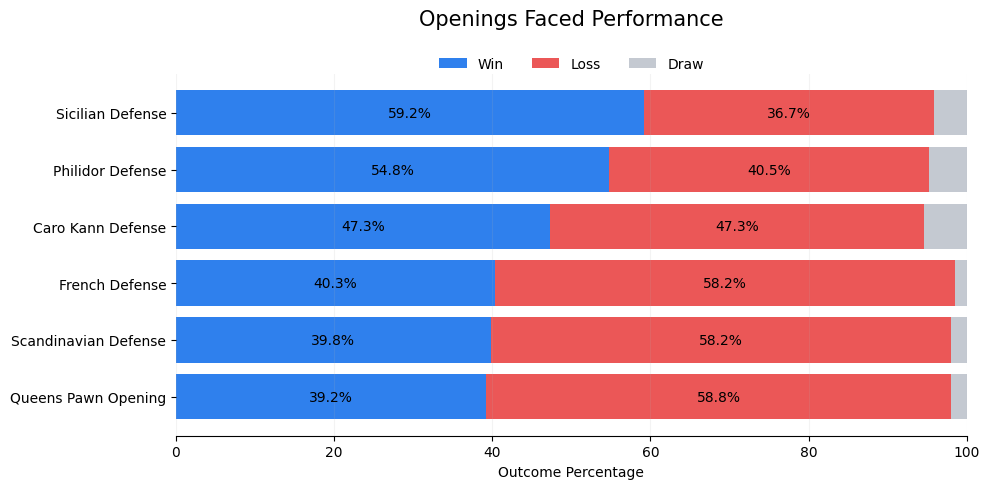

In [14]:

win_color = "#2F80ED"
loss_color = "#EB5757"
draw_color = "#C4C9D1"

plt.figure(figsize=(10, 5))

plt.barh(
    opponent_opening["opening_family"],
    opponent_opening["win_percentage"],
    label="Win",
    color=win_color
)

plt.barh(
    opponent_opening["opening_family"],
    opponent_opening["loss_percentage"],
    left=opponent_opening["win_percentage"],
    label="Loss",
    color=loss_color
)


plt.barh(
    opponent_opening["opening_family"],
    opponent_opening["draw_percentage"],
    left=(
        opponent_opening["win_percentage"]
        + opponent_opening["loss_percentage"]
    ),
    label="Draw",
    color=draw_color
)

plt.title(
    "Openings Faced Performance",
    fontsize=15,
    pad=35
)

plt.legend(
    ncol=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08)
)
plt.xlabel("Outcome Percentage")
plt.ylabel("")

plt.xlim(0, 100)


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.grid(axis="x", alpha=0.15)
ax_faced = plt.gca()

for i, row in opponent_opening.reset_index(drop=True).iterrows():
    win = row["win_percentage"]
    loss = row["loss_percentage"]

    ax_faced.text(
        win / 2,
        i,
        f"{win:.1f}%",
        ha="center",
        va="center"
    )

    ax_faced.text(
        win + loss / 2,
        i,
        f"{loss:.1f}%",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.savefig('mpl_test_plots/openings_faced_performance.png'
)

plt.show()

**Finding:** Opening results vary more noticeably than performance by color. Some commonly played and faced openings are associated with substantially stronger or weaker results, suggesting that my openings may be an important area for improvement.

## Performance Following a Win or Loss

I compared outcomes based on the result of the previous game to see whether performance differed after wins and losses.

In [15]:
previous_plot = pd.DataFrame({
    'previous_result' : ['After Win', 'After Loss'],
    'win' : [previous.loc[0, 'win_percent_after_wins'], previous.loc[0, 'win_percent_after_loss']],
    'loss' : [previous.loc[0,'loss_percent_after_wins'], previous.loc[0, 'loss_percent_after_loss']],
    'draw' : [previous.loc[0, 'draw_percent_after_wins'], previous.loc[0, 'draw_percent_after_loss']]
             
})

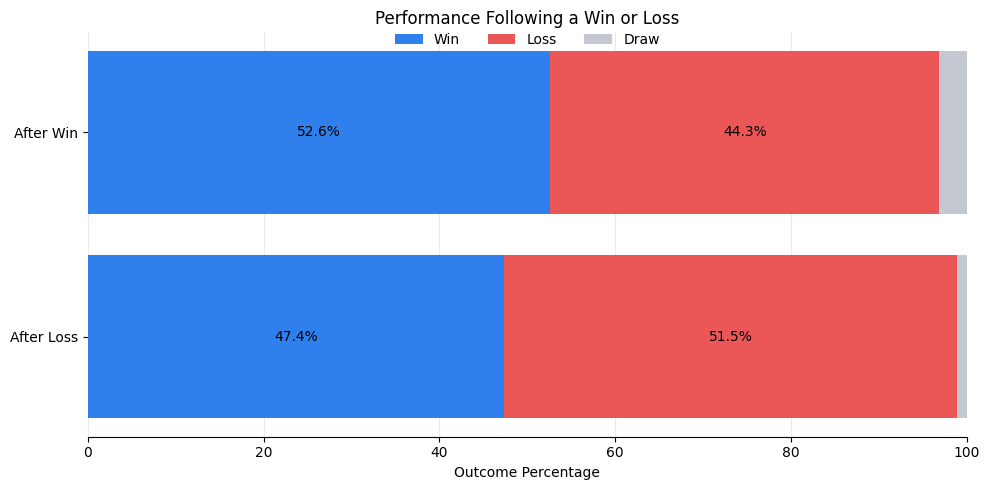

In [16]:
win_color = "#2F80ED"
loss_color = "#EB5757"
draw_color = "#C4C9D1"

fig_previous, ax_previous = plt.subplots(figsize=(10, 5))

ax_previous.barh(
    previous_plot["previous_result"],
    previous_plot["win"],
    label="Win",
    color=win_color
)

ax_previous.barh(
    previous_plot["previous_result"],
    previous_plot["loss"],
    left=previous_plot["win"],
    label="Loss",
    color=loss_color
)


ax_previous.barh(
    previous_plot["previous_result"],
    previous_plot["draw"],
    left=(
        previous_plot["win"]
        + previous_plot["loss"]
    ),
    label="Draw",
    color=draw_color
)

ax_previous.legend(
    ncol=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03)
)
ax_previous.set_title("Performance Following a Win or Loss")
ax_previous.set_xlabel("Outcome Percentage")
ax_previous.set_ylabel("")
ax_previous.set_xlim(0, 100)


ax_previous.grid(axis="x", alpha=0.25)
ax_previous.set_axisbelow(True)

ax_previous.spines["top"].set_visible(False)
ax_previous.spines["right"].set_visible(False)
ax_previous.spines["left"].set_visible(False)

for i, row in previous_plot.reset_index(drop=True).iterrows():
    win = row["win"]
    loss = row["loss"]

    ax_previous.text(
        win / 2,
        i,
        f"{win:.1f}%",
        ha="center",
        va="center"
    )

    ax_previous.text(
        win + loss / 2,
        i,
        f"{loss:.1f}%",
        ha="center",
        va="center"
    )

ax_previous.invert_yaxis()

plt.tight_layout()

plt.savefig(
    "mpl_test_plots/previous_game_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Finding:** Win rate is 52.6% following a win compared with 47.4% following a loss. This shows a clear association between the previous game's result and the next game's outcome, though it should not be interpreted as a causal effect.